# Converting tiff to OME-zarr

Test converting different tiffs to OME-zarr

In [19]:
import zarr
import tifffile
import dask_image.imread
from bioio_ome_zarr.writers import OMEZarrWriter
import matplotlib.pyplot as plt

## Read images

In [31]:
filepath_seg = "data/box1-2_all.tif"
filepath_raw = "data/mnemiopsis-box1-2.tif"

tiffstack_seg = dask_image.imread.imread(filepath_seg)
tiffstack_raw = dask_image.imread.imread(filepath_raw)

tiffstack_seg.shape
tiffstack_raw.shape

(128, 1000, 1000)

Axes seem to be different than in the course exercises. Z axis seems to be first, but check x and y.

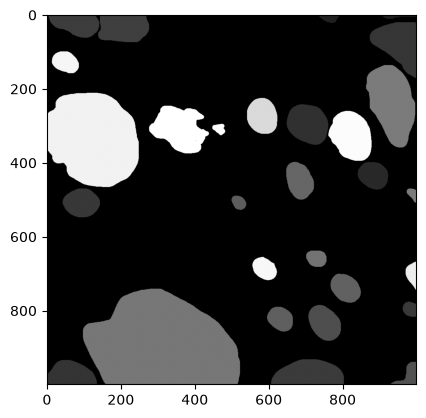

In [21]:
plt.imshow(tiffstack_seg[1, :, :], cmap="gray")

Ok, x and y axes seem to be correct, this image looks the same as when I open it in Fiji

## Create OME-zarr file

In [34]:
compressors = zarr.codecs.BloscCodec(cname="zstd", clevel=3)
seg_zarr = zarr.create_array(
    store="data/seg.zarr",
    shape=tiffstack_seg.shape,
    chunks=(64, 64, 64),
    dtype=tiffstack_seg.dtype,
    compressors=compressors,
    dimension_names=["z", "x", "y"],
)

In [35]:
%%time

# Copy the data into the zarr array
seg_zarr[:] = tiffstack_seg

CPU times: user 1min 54s, sys: 30.4 s, total: 2min 24s
Wall time: 1min 53s


## Add OME metadata

In [37]:
from ome_zarr_models.v05 import Image
from ome_zarr_models.v05.axes import Axis
from pydantic_zarr.v3 import ArraySpec

seg_ome_zarr = Image.new(
    array_specs=[ArraySpec.from_zarr(seg_zarr)],
    paths=["level0"],
    axes=[
        Axis(name="z", type="space", unit="um"),
        Axis(name="x", type="space", unit="um"),
        Axis(name="y", type="space", unit="um"),
    ],
    global_scale=[0.0500, 0.0028, 0.0028],
    scales=[[1, 1, 1]],
    translations=[[0, 0, 0]],
    name="mnemi_seg",
)


## Add scale pyramid

## add raw data stack